## **당뇨병 예측**



#### **모듈, 데이터 가져오기 및 학습 데이터와 예측할 데이터 준비**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

data = load_diabetes()
df_X = data.data
df_y = data.target


X = np.array(df_X)
y = np.array(df_y)


print(type(X), X.dtype)
print(type(y), y.dtype)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # 20퍼를 테스트 데이터로 삼음 랜덤시드 고정
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# df = pd.DataFrame(data.data, columns=data.feature_names)
# df["target"] = data.target
# print("\n=== DataFrame 미리보기 ===")
# print(df.head())
# print("\n=== DataFrame info ===")
# df.info()

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64
(353, 10) (353,)
(89, 10) (89,)


#### **모델 준비하기**

##### **모델 및 함수 정의**

In [2]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

def model(X, W, b):  # 입력 X와 가중치 W, 편향 b로 선형회귀 예측값을 계산
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]  
    predictions += b
    return predictions

def MSE(a, b):  # 예측과 정답 차이의 제곱 평균
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

def loss(X, W, b, y):  # 예측과 정답의 MSE 손실 계산
    predictions = model(X, W, b) 
    L = MSE(predictions, y)
    return L

def gradient(X, W, b, y):  # 손실을 줄이기 위한 W, b의 기울기 계산
    N = len(y) 

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

10


#### **학습률 설정하기 (하이퍼파라미터)**

In [3]:
LEARNING_RATE = 0.15  # 여러 번 수정하다 0.15 수준에서 최적에 가깝다고 생각하는 값이라 생각함

#### **모델 학습하기**

In [4]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 1000001):   # 크게 문제될 것 없는 것 같아 무식하게 100만번 학습하기로 함
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5108.7270
Iteration 200 : Loss 4502.9536
Iteration 300 : Loss 4106.9908
Iteration 400 : Loss 3839.3272
Iteration 500 : Loss 3651.6097
Iteration 600 : Loss 3514.9217
Iteration 700 : Loss 3411.7758
Iteration 800 : Loss 3331.4354
Iteration 900 : Loss 3267.1769
Iteration 1000 : Loss 3214.6826
Iteration 1100 : Loss 3171.0957
Iteration 1200 : Loss 3134.4600
Iteration 1300 : Loss 3103.3868
Iteration 1400 : Loss 3076.8546
Iteration 1500 : Loss 3054.0861
Iteration 1600 : Loss 3034.4733
Iteration 1700 : Loss 3017.5286
Iteration 1800 : Loss 3002.8539
Iteration 1900 : Loss 2990.1197
Iteration 2000 : Loss 2979.0501
Iteration 2100 : Loss 2969.4122
Iteration 2200 : Loss 2961.0085
Iteration 2300 : Loss 2953.6707
Iteration 2400 : Loss 2947.2548
Iteration 2500 : Loss 2941.6375
Iteration 2600 : Loss 2936.7127
Iteration 2700 : Loss 2932.3893
Iteration 2800 : Loss 2928.5888
Iteration 2900 : Loss 2925.2433
Iteration 3000 : Loss 2922.2942
Iteration 3100 : Loss 2919.6911
Iteration 3200 : 

#### **test 데이터 성능 확인**

In [5]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2900.129003448637)

#### **시각화**


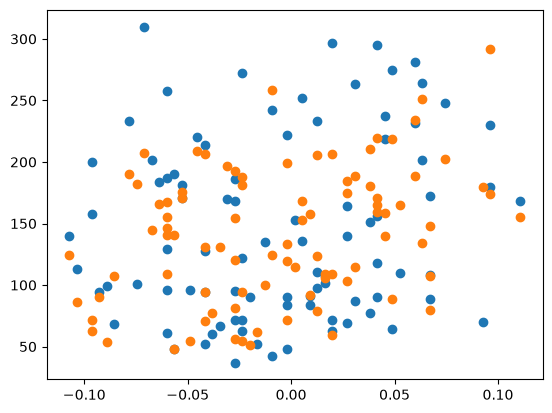

In [6]:
plt.scatter(X_test[:, 0], y_test) # 테스트 실제 데이터
plt.scatter(X_test[:, 0], prediction) # 데이터 예측한 오랜지색 점
plt.show()

#### **더 오차를 줄이려면 더 많은 데이터와 학습횟수가 있어야 할 것 같음.**


##### **100만번 학습에서는 0.15가 최적에 가까움. 학습 횟수를 늘려도 유의미하지 않기에 100만번으로 설정함.**

##### **다만 다양하게 시도를 해봐도 유의미하게 오차를 줄이지 못함.**

##### **또한 너무 훈련 데이터에 치중되어 과적합도 크게 우려됨**